# Cell–cell communication with CellChat

Runs the real **CellChat** ([Jin et al. 2021](https://github.com/jinworks/CellChat)) on a simulated
dissociated scRNA sample, using a ligand–receptor database that `iscc` invented over its own genes,
and asks whether CellChat finds the one channel that was actually wired into the simulation.

Communication is inferred from **dissociated scRNA** in practice — CellPhoneDB, CellChat's original
mode, NATMI and LIANA all score cell *types* from mean ligand and receptor expression, with no
positions at all. So that is the sample here.

The database is the interesting part. `iscc` emits candidate pairs over its own gene ids: **one is
wired** into the simulated channel, and the rest are unwired decoys. So "did the tool find it?" is a
real question with a known answer, rather than a plausibility check.

**R notebook**, kernel `R (iscc-cellchat)`, no simulation. Generated once by
`python validation/make_analysis_data.py --only cci`:

| file | what it is | who sees it |
|---|---|---|
| `sc_counts.csv`, `sc_meta.csv` | the dissociated sample: genes × cells, and one label per cell | the tool |
| `iscc_interaction_input.csv` + 3 more | the ligand–receptor database, in `updateCellChatDB()` format | the tool |
| `truth_pairs.csv` | which pair is wired, and who emits it | scoring only |
| `truth_clone_correlation.csv` | how clone-determined each candidate pair is | scoring only |

In [1]:
source("r_preamble.R")
suppressMessages({ library(CellChat); library(Matrix) })

data_dir <- analysis_dir("cci")
counts <- as.matrix(read.csv(file.path(data_dir, "sc_counts.csv"), row.names = 1,
                             check.names = FALSE))            # genes x cells
meta <- read.csv(file.path(data_dir, "sc_meta.csv"), row.names = 1, check.names = FALSE)
meta$group <- factor(meta$group)
meta$samples <- factor("sample1")                             # must be a factor
rownames(meta) <- colnames(counts)

cat(sprintf("sample: %d genes x %d cells across %d groups: %s\n",
            nrow(counts), ncol(counts), nlevels(meta$group),
            paste(levels(meta$group), collapse = ", ")))

sample: 6000 genes x 4000 cells across 6 groups: clone0, clone1, clone2, epithelial, immune, stromal


## The database iscc emitted

`updateCellChatDB()` builds a CellChat database from a plain ligand/receptor table — it fills in the
pathway and interaction names itself. Two constraints are worth stating because **both fail silently**:

* every gene the database references must also appear in `geneInfo`, or the pair is dropped without
  an error and simply never appears in the output;
* `annotation` must be one of CellChat's four recognised strings, or it becomes `NA` and the
  diffusive-versus-contact split is corrupted.

`iscc` writes the tables so that both hold, and the check below is the one that catches the first
failure class outright.

In [2]:
read_tbl <- function(f, ...) read.csv(file.path(data_dir, f), check.names = FALSE,
                                      stringsAsFactors = FALSE, ...)
interaction <- read_tbl("iscc_interaction_input.csv", row.names = 1)
geneInfo    <- read_tbl("iscc_geneInfo_input.csv")
complex_in  <- read_tbl("iscc_complex_input.csv")
cofactor_in <- read_tbl("iscc_cofactor_input.csv")

db.iscc <- updateCellChatDB(db = interaction, gene_info = geneInfo,
                            other_info = list(complex = complex_in, cofactor = cofactor_in))

expected <- sort(unique(c(interaction$ligand, interaction$receptor)))
present  <- sort(unique(extractGene(db.iscc)))
stopifnot(setequal(expected, present))
cat(sprintf("database: %d candidate pairs over %d genes; every referenced gene survived\n",
            nrow(interaction), length(present)))
head(interaction[, c("ligand", "receptor", "annotation")], 3)

database: 250 candidate pairs over 500 genes; every referenced gene survived


,ligand,receptor,annotation
,<chr>,<chr>,<chr>
G_2_471_G_7_41,G_2_471,G_7_41,Secreted Signaling
G_4_407_G_10_201,G_4_407,G_10_201,Secreted Signaling
G_7_105_G_11_285,G_7_105,G_11_285,Secreted Signaling


## Run CellChat

The standard pipeline. `normalizeData()` takes the raw count **matrix** and returns log-normalised
data, so it runs *before* the object is built — handing `createCellChat()` a bare matrix tells it the
data is already normalised.

In [3]:
data.norm <- normalizeData(counts)
cc <- createCellChat(object = data.norm, meta = meta, group.by = "group")
cc@DB <- db.iscc

cc <- subsetData(cc)
cc <- identifyOverExpressedGenes(cc)
cc <- identifyOverExpressedInteractions(cc)
cc <- computeCommunProb(cc, type = "triMean", nboot = 100)
cc <- filterCommunication(cc, min.cells = 10)

net <- subsetCommunication(cc)
cat(sprintf("\n%d communication edges over %d ligand-receptor pairs\n",
            nrow(net), length(unique(net$interaction_name))))

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  clone0, clone1, clone2, epithelial, immune, stromal 


The number of highly variable ligand-receptor pairs used for signaling inference is 250 


triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-08-27 17:49:07.997905]"


[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-08-27 17:49:21.440082]"



1263 communication edges over 250 ligand-receptor pairs


## Did it find the wired channel?

Rank the pairs by **communication probability**, not by p-value. CellChat computes probability on
group-averaged expression, so with enough cells almost every pair earns a "significant" edge — a dense,
all-significant network is the expected background here and p-values do not separate anything.

In [4]:
truth <- read.csv(file.path(data_dir, "truth_pairs.csv"), stringsAsFactors = FALSE)
wired <- truth$interaction_name[as.logical(truth$wired)][1]

by_pair <- sort(tapply(net$prob, net$interaction_name, max), decreasing = TRUE)
rank_of <- match(wired, names(by_pair))

cat(sprintf("wired pair : %s\n", wired))
if (is.na(rank_of)) {
  cat("The wired pair was not scored: CellChat's over-expression filter dropped it.\n")
} else {
  cat(sprintf("rank       : %d of %d scored (%d in the database)\n",
              rank_of, length(by_pair), nrow(truth)))
  cat(sprintf("probability: %.3f   (best decoy %.3f)\n",
              by_pair[[wired]], max(by_pair[names(by_pair) != wired])))
}

wired pair : G_2_471_G_7_41


rank       : 1 of 250 scored (250 in the database)
probability: 0.378   (best decoy 0.227)


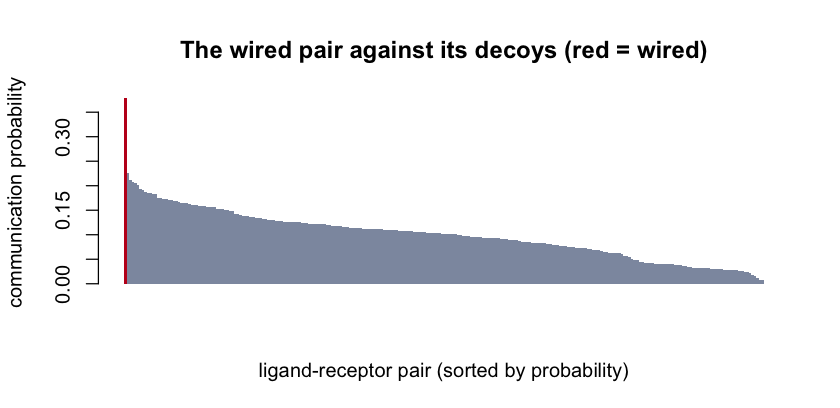

In [5]:
options(repr.plot.width = 7, repr.plot.height = 3.4)
cols <- ifelse(names(by_pair) == wired, "#c1121f", "#8d99ae")
barplot(as.numeric(by_pair), col = cols, border = NA, space = 0,
        xlab = "ligand-receptor pair (sorted by probability)",
        ylab = "communication probability",
        main = "The wired pair against its decoys (red = wired)")

## Who is talking to whom

Recovering the *pair* is one claim; recovering the *direction* is another. The channel was wired so
that one cell type emits and the others respond, so the strongest edge for the wired pair should run
from that emitter to the cells carrying the receptor.

In [6]:
w <- net[net$interaction_name == wired, c("source", "target", "prob")]
w <- w[order(-w$prob), ]
cat(sprintf("emitter in the simulation: %s\n\n", truth$emitter[1]))
head(w, 5)

emitter in the simulation: immune



,source,target,prob
,<fct>,<fct>,<dbl>
1,immune,stromal,0.3781556
2,stromal,stromal,0.1737626


CellChat's own aggregated view of the whole network — the standard summary of a communication
analysis, with edge weight showing how much signalling each pair of groups carries.

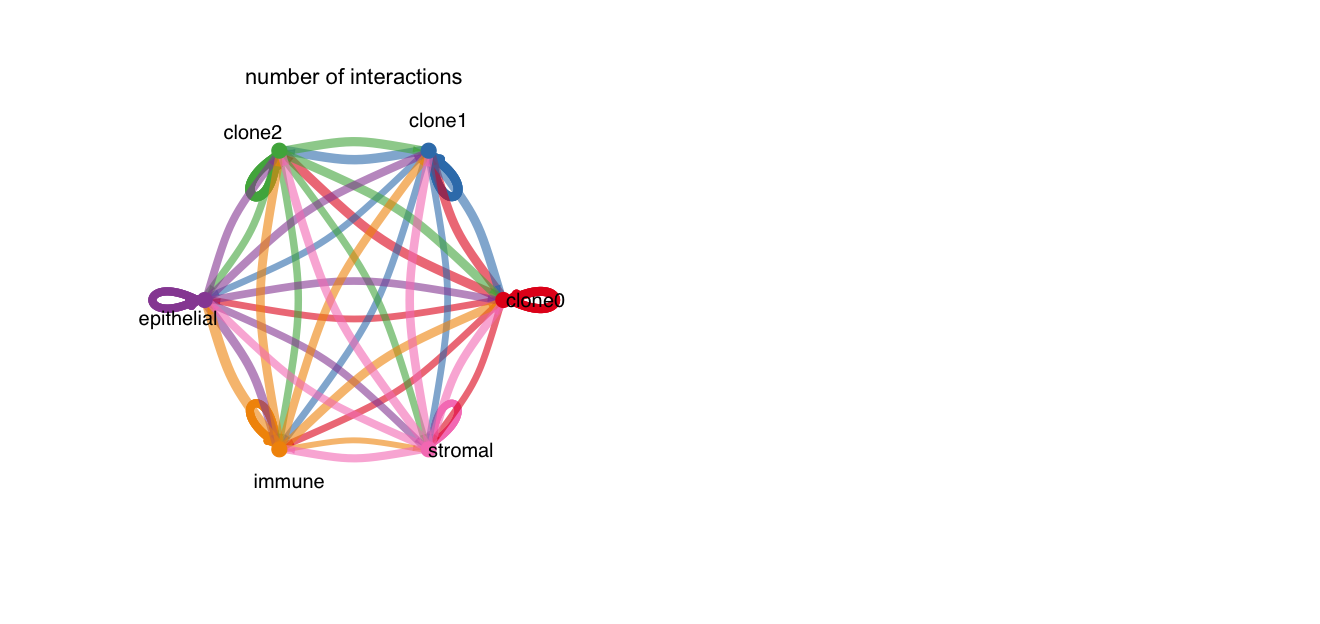

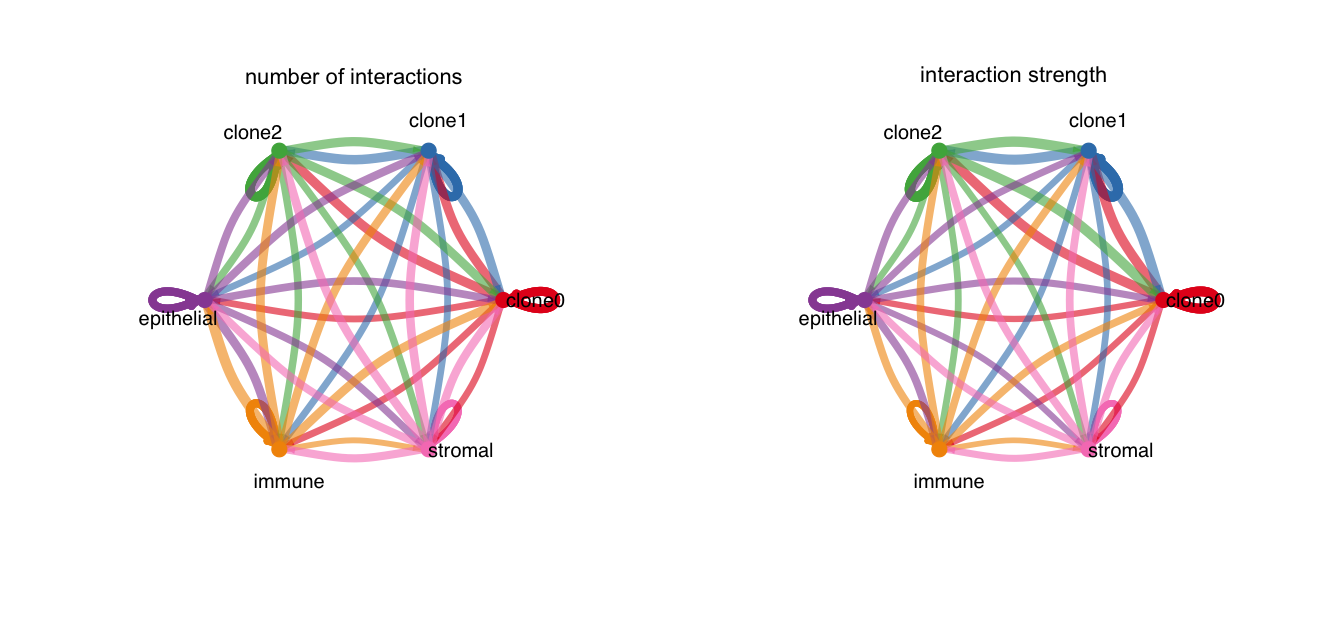

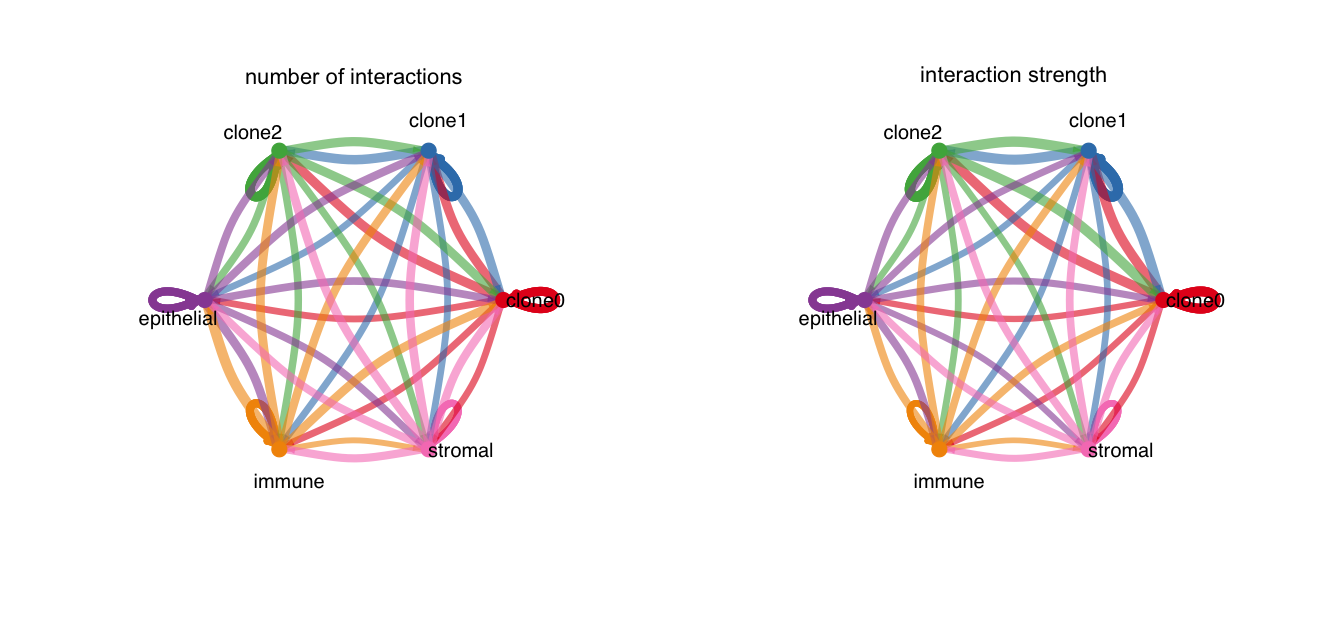

In [7]:
cc <- aggregateNet(cc)
options(repr.plot.width = 11, repr.plot.height = 5.2)
par(mfrow = c(1, 2), xpd = TRUE)
netVisual_circle(cc@net$count,  weight.scale = TRUE, label.edge = FALSE,
                 title.name = "number of interactions")
netVisual_circle(cc@net$weight, weight.scale = TRUE, label.edge = FALSE,
                 title.name = "interaction strength")

## The confound worth knowing about

Neighbouring cells in a tumour are usually **clonally related**, so their expression correlates whether
or not they are communicating. That makes some candidate pairs look coordinated for reasons that have
nothing to do with signalling.

`iscc` measures this per candidate rather than designing it: pairs are drawn at random and simply land
on clone-varying regions of the genome by chance. The distribution below is emergent, and it is the
background any communication method is working against — a simulator without clones cannot produce it
at all.

median clone-correlation across candidates: 1.00


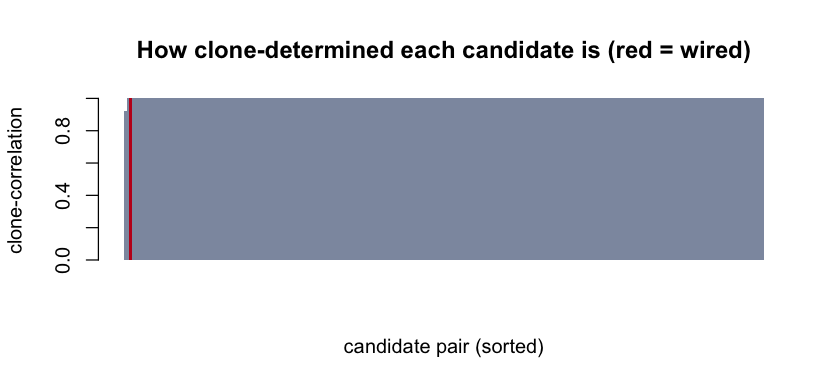

In [8]:
cc_tab <- read.csv(file.path(data_dir, "truth_clone_correlation.csv"), stringsAsFactors = FALSE)
o <- order(cc_tab$eta_max)
options(repr.plot.width = 7, repr.plot.height = 3.2)
barplot(cc_tab$eta_max[o], border = NA, space = 0,
        col = ifelse(as.logical(cc_tab$wired)[o], "#c1121f", "#8d99ae"),
        xlab = "candidate pair (sorted)", ylab = "clone-correlation",
        main = "How clone-determined each candidate is (red = wired)")
cat(sprintf("median clone-correlation across candidates: %.2f\n", median(cc_tab$eta_max)))

## What this shows

Handed a database it has never seen, over genes that do not exist outside the simulation, CellChat
runs its ordinary pipeline and ranks the wired pair at the top of the screen — and its strongest edge
for that pair runs from the emitting cell type to the receivers. The data `iscc` produces is in the
form this class of method actually reads.

The dissociated sample carries no positions, which is what the method expects. To see the same channel
laid out in tissue, [Spatial transcriptomics](assay_spatial.ipynb) puts a Visium slide over the same
field; [Single-cell RNA](assay_scrna.ipynb) covers how the dissociated sample itself is generated.